# NFL Playcall Evaluation

## Abstract
Description

## Imports

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model

import nfl_data_py as nfl
import dowhy
import networkx as nx
from cdt.causality.graph import LiNGAM
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [47]:
years = [2022, 2023]
list(nfl.see_pbp_cols())

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

In [132]:
pbp_data_2018 = nfl.import_pbp_data(years)
pbp_data_2018.head()

2022 done.
2023 done.
Downcasting floats.


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,None,None,None,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,43.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,68.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,89.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,1.0,ANGLE,ZONE_COVERAGE,COVER_2,NaN,NaN,NaN,NaN,NaN,NaN
4,115.0,2022_01_BAL_NYJ,2022091107,NYJ,BAL,REG,1,NYJ,home,BAL,...,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN


## Game State
Quarter and Half, Time, Yard line, Down & Distance

## Offensive Personnel
Team, player number, player rating, (detailed player position ratings)

## Formation
Gun vs Under Center, Reciever groupings, Tight End position, motion

## Defensive Personnel
Team, player number, player rating, (detailed player position rating)

## Playcall
Defensive man-zone type, defensive coverage, blitz

## Play Result Stats
Yards gained/lost, pressure?, route, scramble?, run or pass

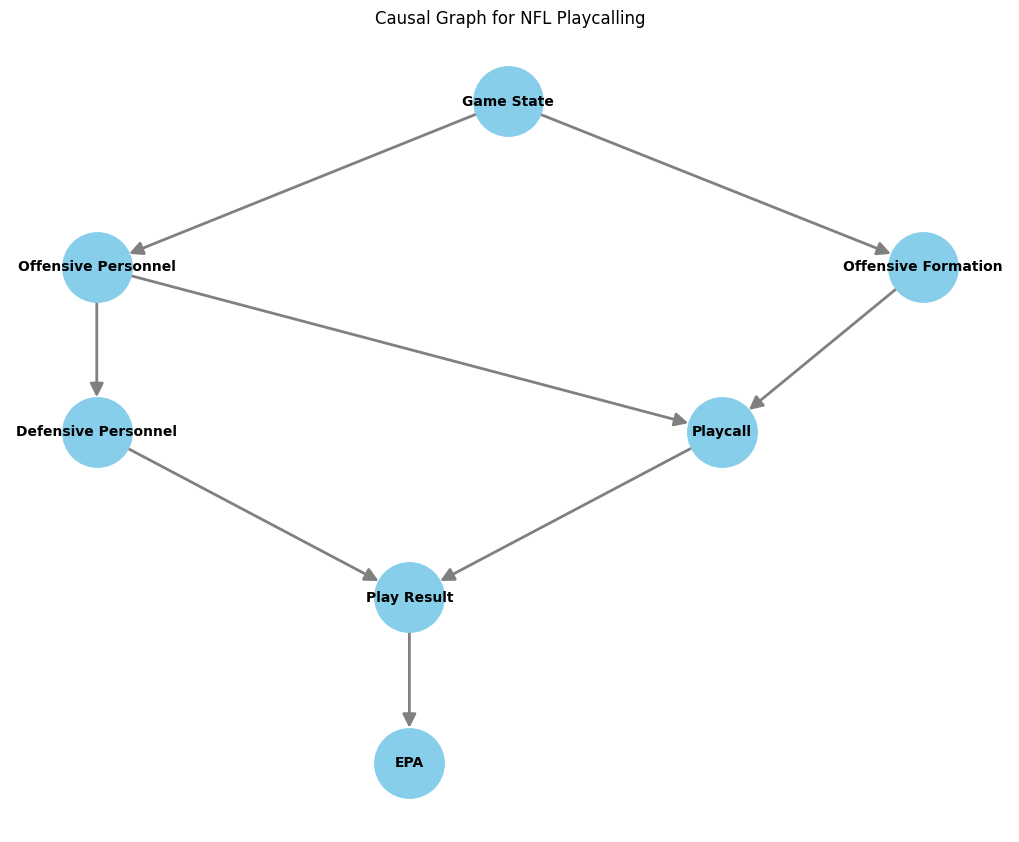

In [111]:
edge_list = [('Game State', 'Offensive Personnel'), ('Game State', 'Offensive Formation'), ('Offensive Personnel', 'Defensive Personnel'),
             ('Offensive Personnel', 'Playcall'), ('Offensive Formation','Playcall'), ('Playcall', 'Play Result'), ('Defensive Personnel', 'Play Result'), 
             ('Play Result', 'EPA')]

visual_graph = nx.DiGraph(edge_list)

# 2. Use the 'dot' layout engine from Graphviz
# This is the key to the top-to-bottom flowchart layout
# 'prog' specifies the layout algorithm. 'dot' is for hierarchical layouts.
try:
    pos = nx.drawing.nx_pydot.graphviz_layout(visual_graph, prog='dot')
except ImportError:
    # Fallback for systems without Graphviz/pydot
    print("Graphviz and pydot are not installed. Using a spring layout as a fallback.")
    print("For a top-to-bottom layout, please install them.")
    pos = nx.spring_layout(visual_graph)


# 3. Draw the graph using matplotlib
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability

nx.draw(visual_graph, pos,
        with_labels=True,
        node_size=2500,
        node_color='skyblue',
        font_size=10,
        font_weight='bold',
        width=2.0,
        edge_color='gray',
        arrowsize=20)

plt.title("Causal Graph for NFL Playcalling")
plt.show()

In [141]:
remove_play = ['special']
game_state_columns = ['qtr', 'quarter_seconds_remaining', 'yardline_100', 'down', 'ydstogo']
formation_columns = ['offense_formation', 'no_huddle']
# playcall_columns = ['defense_personnel', 'defenders_in_box', 'number_of_pass_rushers', 'defense_man_zone_type', 'defense_coverage_type']
playcall_columns = ['defenders_in_box', 'defense_coverage_type']
play_result_columns = ['yards_gained', 'series_success', 'qb_scramble', 'run_location', 'run_gap', 'route']
epa_column = ['epa']
play_type_column = ['play_type']
cols = remove_play + game_state_columns + formation_columns + playcall_columns + epa_column + play_type_column
pbp_filtered_data_2018 = pbp_data_2018[cols]
pbp_filtered_data_2018

,special,qtr,quarter_seconds_remaining,yardline_100,down,ydstogo,offense_formation,no_huddle,defenders_in_box,defense_coverage_type,epa,play_type
0,0.0,1.0,900.0,NaN,NaN,0.0,None,0.0,NaN,None,0.000000,None
1,1.0,1.0,900.0,35.0,NaN,0.0,None,0.0,NaN,None,-0.443521,kickoff
2,0.0,1.0,896.0,78.0,1.0,10.0,SINGLEBACK,0.0,7.0,None,1.468819,run
3,0.0,1.0,869.0,59.0,1.0,10.0,SHOTGUN,1.0,6.0,COVER_2,-0.492192,pass
4,0.0,1.0,865.0,59.0,2.0,10.0,SINGLEBACK,1.0,7.0,None,-0.325931,run
...,...,...,...,...,...,...,...,...,...,...,...,...
99094,0.0,5.0,127.0,32.0,3.0,1.0,SHOTGUN,0.0,6.0,COVER_2,1.728891,run
99095,0.0,5.0,86.0,13.0,1.0,10.0,SHOTGUN,0.0,6.0,None,-0.330699,run
99096,0.0,5.0,50.0,10.0,2.0,7.0,SHOTGUN,0.0,6.0,COVER_4,-0.637115,pass
99097,0.0,5.0,6.0,3.0,1.0,3.0,SHOTGUN,0.0,6.0,COVER_4,3.102806,pass


In [188]:
# Remove speical plays and no-plays (flags)
pbp_clean_data_2018 = pbp_filtered_data_2018[pbp_filtered_data_2018['special'] != 1]
pbp_clean_data_2018 = pbp_clean_data_2018[pbp_clean_data_2018['play_type'] != 'no_play']
pbp_clean_data_2018 = pbp_clean_data_2018.dropna(subset=['down'])

# Clip defenders in box to group together special plays (end of game or goal-line)
pbp_clean_data_2018['defenders_in_box'] = pbp_clean_data_2018['defenders_in_box'].clip(lower=3, upper=8)

# Drop unnecessary columns
pbp_clean_data_2018 = pbp_clean_data_2018.drop(play_type_column, axis=1)

# Fill NaN values 
pbp_clean_data_2018 = pbp_clean_data_2018.fillna(0)

print(pbp_clean_data_2018.dtypes)
pbp_clean_data_2018

special                      float32
qtr                          float32
quarter_seconds_remaining    float32
yardline_100                 float32
down                         float32
ydstogo                      float32
offense_formation             object
no_huddle                    float32
defenders_in_box             float32
defense_coverage_type         object
epa                          float32
dtype: object


,special,qtr,quarter_seconds_remaining,yardline_100,down,ydstogo,offense_formation,no_huddle,defenders_in_box,defense_coverage_type,epa
2,0.0,1.0,896.0,78.0,1.0,10.0,SINGLEBACK,0.0,7.0,0,1.468819
3,0.0,1.0,869.0,59.0,1.0,10.0,SHOTGUN,1.0,6.0,COVER_2,-0.492192
4,0.0,1.0,865.0,59.0,2.0,10.0,SINGLEBACK,1.0,7.0,0,-0.325931
5,0.0,1.0,841.0,54.0,3.0,5.0,SHOTGUN,1.0,7.0,COVER_3,-2.402200
7,0.0,1.0,822.0,72.0,1.0,10.0,SINGLEBACK,0.0,7.0,COVER_3,0.075127
...,...,...,...,...,...,...,...,...,...,...,...
99093,0.0,5.0,168.0,37.0,2.0,6.0,SHOTGUN,0.0,6.0,COVER_1,0.552538
99094,0.0,5.0,127.0,32.0,3.0,1.0,SHOTGUN,0.0,6.0,COVER_2,1.728891
99095,0.0,5.0,86.0,13.0,1.0,10.0,SHOTGUN,0.0,6.0,0,-0.330699
99096,0.0,5.0,50.0,10.0,2.0,7.0,SHOTGUN,0.0,6.0,COVER_4,-0.637115


In [189]:
# One hot encoding
one_hot_cols = pbp_clean_data_2018.select_dtypes(include=['object']).columns.tolist()
one_hot_cols = [col for col in one_hot_cols if col not in set(playcall_columns)]
pbp_model_data_2018 = pd.get_dummies(pbp_clean_data_2018, columns=one_hot_cols)
pbp_model_data_2018

,special,qtr,quarter_seconds_remaining,yardline_100,down,ydstogo,no_huddle,defenders_in_box,defense_coverage_type,epa,offense_formation_0,offense_formation_EMPTY,offense_formation_I_FORM,offense_formation_JUMBO,offense_formation_PISTOL,offense_formation_SHOTGUN,offense_formation_SINGLEBACK,offense_formation_UNDER CENTER,offense_formation_WILDCAT
2,0.0,1.0,896.0,78.0,1.0,10.0,0.0,7.0,0,1.468819,0,0,0,0,0,0,1,0,0
3,0.0,1.0,869.0,59.0,1.0,10.0,1.0,6.0,COVER_2,-0.492192,0,0,0,0,0,1,0,0,0
4,0.0,1.0,865.0,59.0,2.0,10.0,1.0,7.0,0,-0.325931,0,0,0,0,0,0,1,0,0
5,0.0,1.0,841.0,54.0,3.0,5.0,1.0,7.0,COVER_3,-2.402200,0,0,0,0,0,1,0,0,0
7,0.0,1.0,822.0,72.0,1.0,10.0,0.0,7.0,COVER_3,0.075127,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99093,0.0,5.0,168.0,37.0,2.0,6.0,0.0,6.0,COVER_1,0.552538,0,0,0,0,0,1,0,0,0
99094,0.0,5.0,127.0,32.0,3.0,1.0,0.0,6.0,COVER_2,1.728891,0,0,0,0,0,1,0,0,0
99095,0.0,5.0,86.0,13.0,1.0,10.0,0.0,6.0,0,-0.330699,0,0,0,0,0,1,0,0,0
99096,0.0,5.0,50.0,10.0,2.0,7.0,0.0,6.0,COVER_4,-0.637115,0,0,0,0,0,1,0,0,0


# Build Causal Model

In [149]:
new_cols = list(pbp_model_data_2018.columns)
new_game_state_cols = []
new_formation_cols = []
new_playcall_cols = []
new_play_result_cols = []

# Update Game State Cols
for game_state_col in game_state_columns:
    hot_cols = list(filter(lambda x: game_state_col in x, new_cols))
    new_game_state_cols += hot_cols


# Update Formation Cols
for formation_col in formation_columns:
    hot_cols = list(filter(lambda x: formation_col in x, new_cols))
    new_formation_cols += hot_cols

# Update Playcall Cols
for playcall_col in playcall_columns:
    hot_cols = list(filter(lambda x: playcall_col in x, new_cols))
    new_playcall_cols += hot_cols

# Update Play Result Cols
for play_result_col in play_result_columns:
    hot_cols = list(filter(lambda x: play_result_col in x, new_cols))
    new_play_result_cols += hot_cols

In [150]:
edge_list = []

# Game State to Offense Formation Edges
for game_state_col in new_game_state_cols:
    for off_formation_col in new_formation_cols:
        edge_list.append((game_state_col, off_formation_col))

# Formation to Playcall Edges
for off_formation_col in new_formation_cols:
    for playcall_col in new_playcall_cols:
        edge_list.append((off_formation_col, playcall_col))


# Playcall to Play Result Edges
for playcall_col in new_playcall_cols:
    for result_col in new_play_result_cols:
        edge_list.append((playcall_col, result_col))

# Play Result to EPA Edges
for result_col in new_play_result_cols:
    edge_list.append((result_col, epa_column[0]))

In [159]:
print(edge_list)
causal_graph = nx.DiGraph(edge_list)

[('qtr', 'offense_formation_EMPTY'), ('qtr', 'offense_formation_I_FORM'), ('qtr', 'offense_formation_JUMBO'), ('qtr', 'offense_formation_PISTOL'), ('qtr', 'offense_formation_SHOTGUN'), ('qtr', 'offense_formation_SINGLEBACK'), ('qtr', 'offense_formation_WILDCAT'), ('qtr', 'no_huddle'), ('quarter_seconds_remaining', 'offense_formation_EMPTY'), ('quarter_seconds_remaining', 'offense_formation_I_FORM'), ('quarter_seconds_remaining', 'offense_formation_JUMBO'), ('quarter_seconds_remaining', 'offense_formation_PISTOL'), ('quarter_seconds_remaining', 'offense_formation_SHOTGUN'), ('quarter_seconds_remaining', 'offense_formation_SINGLEBACK'), ('quarter_seconds_remaining', 'offense_formation_WILDCAT'), ('quarter_seconds_remaining', 'no_huddle'), ('yardline_100', 'offense_formation_EMPTY'), ('yardline_100', 'offense_formation_I_FORM'), ('yardline_100', 'offense_formation_JUMBO'), ('yardline_100', 'offense_formation_PISTOL'), ('yardline_100', 'offense_formation_SHOTGUN'), ('yardline_100', 'offens

In [160]:
model = dowhy.CausalModel(
    data=pbp_model_data_2018,
    treatment=new_playcall_cols,
    outcome=epa_column,
    graph="\n".join(nx.generate_gml(causal_graph))
)

In [ ]:
result = dowhy.gcm.falsify.falsify_graph(causal_graph, pbp_model_data_2018, plot_histogram=True)
# Summarize the result
print(result)

/Users/pendsec/miniconda3/envs/nfl-analysis/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pendsec/miniconda3/envs/nfl-analysis/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/pendsec/miniconda3/envs/nfl-analysis/lib/python3.10/site-packages/causallearn/utils/KCI/KCI.py:596: RuntimeWarning: invalid value encountered in scalar divide
  k_appr = mean_appr ** 2 / var_appr
/Users/pendsec/miniconda3/envs/nfl-analysis/lib/python3.10/site-packages/causallearn/utils/KCI/KCI.py:597: RuntimeWarning: invalid value encountered in scalar divide
  theta_appr = var_appr / mean_appr
/Users/pendsec/miniconda3/envs/nfl-analysis/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/pends

In [157]:
predicted_causal_graph = LiNGAM().predict(pbp_model_data_2018)

ImportError: R Package pcalg is not available.

# Build XGBoost EPA Prediction Model

In [146]:
pbp_model_data_2018

,special,qtr,quarter_seconds_remaining,yardline_100,down,ydstogo,no_huddle,defenders_in_box,defense_coverage_type,epa,offense_formation_EMPTY,offense_formation_I_FORM,offense_formation_JUMBO,offense_formation_PISTOL,offense_formation_SHOTGUN,offense_formation_SINGLEBACK,offense_formation_UNDER CENTER,offense_formation_WILDCAT
2,0.0,1.0,896.0,78.0,1.0,10.0,0.0,7.0,0,1.468819,0,0,0,0,0,1,0,0
3,0.0,1.0,869.0,59.0,1.0,10.0,1.0,6.0,COVER_2,-0.492192,0,0,0,0,1,0,0,0
4,0.0,1.0,865.0,59.0,2.0,10.0,1.0,7.0,0,-0.325931,0,0,0,0,0,1,0,0
5,0.0,1.0,841.0,54.0,3.0,5.0,1.0,7.0,COVER_3,-2.402200,0,0,0,0,1,0,0,0
7,0.0,1.0,822.0,72.0,1.0,10.0,0.0,7.0,COVER_3,0.075127,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99093,0.0,5.0,168.0,37.0,2.0,6.0,0.0,6.0,COVER_1,0.552538,0,0,0,0,1,0,0,0
99094,0.0,5.0,127.0,32.0,3.0,1.0,0.0,6.0,COVER_2,1.728891,0,0,0,0,1,0,0,0
99095,0.0,5.0,86.0,13.0,1.0,10.0,0.0,6.0,0,-0.330699,0,0,0,0,1,0,0,0
99096,0.0,5.0,50.0,10.0,2.0,7.0,0.0,6.0,COVER_4,-0.637115,0,0,0,0,1,0,0,0


In [199]:
def train_simple_xgboost(plays, epa):
    # Split the data into training and testing sets
    # We use 80% for training and 20% for testing
    X_train, X_test, y_train, y_test = train_test_split(
        plays, epa, test_size=0.2, random_state=42
    )

    # Initialize the XGBoost
    # We set a few basic hyperparameters here:
    # n_estimators: Number of boosting rounds (trees)
    # learning_rate: Step size shrinkage used to prevent overfitting
    # max_depth: Maximum depth of a tree
    model = xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        
    )

    param_dict = {
        'objective': ['reg:squarederror', 'reg:absoluteerror'],
        'n_estimators': [100, 300, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'alpha': [0, 5, 10]
    }

    # 4. Set up GridSearchCV
    # cv=3 means 3-fold Cross-Validation
    # scoring='neg_mean_squared_error' is standard for regression in sklearn
    grid_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dict,
        n_iter=1000,
        cv=3,
        scoring='neg_mean_absolute_error',
        verbose=1,
        n_jobs=-1  # Use all available cores
    )
    
    # 5. Fit the search
    print("Starting Grid Search...")
    grid_search.fit(X_train, y_train)

    # 6. Get the best results
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print(f"Best Hyperparameters: {best_params}")

    # 7. Make predictions
    y_pred = best_model.predict(X_test)

    # 8. Evaluate the model
    r2 = r2_score(y_test, y_pred)

    print(f"R-squared Score: {r2:.4f}")

    # # Optional: Feature Importance
    # # This helps understand which features drove the predictions
    # print("\nFeature Importances (Top 3):")
    # # Get indices of top 3 features
    # sorted_idx = model.feature_importances_.argsort()[::-1][:3]
    # for index in sorted_idx:
    #     print(f"Feature {index}: {model.feature_importances_[index]:.4f}")

    return best_model

In [200]:
model_dict = {}
for (def_in_box, coverage_type), train_data in pbp_model_data_2018.groupby(['defenders_in_box', 'defense_coverage_type']):
    print("Defenders in Box: ", def_in_box)
    print("Coverage Type: ", coverage_type)

    if train_data.size < 100:
        print("Not enough samples \n")
        continue
    
    drop_columns = epa_column + playcall_columns
    training_plays = train_data.drop(columns=drop_columns)
    epa = train_data['epa']

    epa_model = train_simple_xgboost(training_plays, epa)
    model_dict[(def_in_box, coverage_type)] = epa_model
    print("\n")

Defenders in Box:  0.0
Coverage Type:  0
Starting Grid Search...
Fitting 3 folds for each of 1000 candidates, totalling 3000 fits
Best Hyperparameters: {'subsample': 0.6, 'objective': 'reg:squarederror', 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.6, 'alpha': 5}
R-squared Score: -0.5817


Defenders in Box:  3.0
Coverage Type:  0
Starting Grid Search...
Fitting 3 folds for each of 1000 candidates, totalling 3000 fits
Best Hyperparameters: {'subsample': 0.8, 'objective': 'reg:absoluteerror', 'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0, 'alpha': 10}
R-squared Score: 0.3661


Defenders in Box:  3.0
Coverage Type:  2_MAN
Starting Grid Search...
Fitting 3 folds for each of 1000 candidates, totalling 3000 fits
Best Hyperparameters: {'subsample': 0.6, 'objective': 'reg:absoluteerror', 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.9, 'alpha': 5}
R-squared Score: -0.0004


Defende

KeyboardInterrupt: 

# Build NN Based EPA Prediction Model

In [ ]:
# 1. Categorical Branch (Defensive Calls)
call_input = layers.Input(shape=(1,), name='defensive_call')
# Assume 50 unique playcalls; embedding size = 7
call_embed = layers.Embedding(input_dim=50, output_dim=7)(call_input)
call_flat = layers.Flatten()(call_embed)

# 2. Numerical Branch (Situational Data)
num_input = layers.Input(shape=(5,), name='situational_features') # Down, Dist, Yardline, etc.

# 3. Combine Branches
merged = layers.Concatenate()([call_flat, num_input])

# 4. Hidden Layers
x = layers.Dense(64, activation='relu')(merged)
x = layers.Dropout(0.2)(x) # Prevents overfitting to fluke plays
x = layers.Dense(32, activation='relu')(x)

# 5. Output Layer
output = layers.Dense(1, activation='linear')(x) # Continuous EPA prediction

model = Model(inputs=[call_input, num_input], outputs=output)
model.compile(optimizer='adam', loss='huber') # Huber loss is robust to EPA outliers

# Combine EPA Prediction Model into Decision Engine

In [148]:
def aggregate_model(plays, model_dict):
    # Create dataframe for predictions made by models
    preds_df = pd.DataFrame(index=plays.index)

    # Iterate over models and predict EPA
    for playcall, model in model_dict.items():
        preds_df[playcall] = model.predict(plays)
    
    # Pick best playcall for each play
    best_playcalls = preds_df.idxmin(axis=1)
    best_epa = preds_df.min(axis=1)
    
    return best_playcalls, best_epa

In [149]:
# Pull testing data
test_years = [2024]
pbp_data_2024 = nfl.import_pbp_data(test_years)

2024 done.
Downcasting floats.


In [192]:
# Filter and clean test data
pbp_filtered_data_2024 = pbp_data_2024[cols]
pbp_clean_data_2024 = pbp_filtered_data_2024[pbp_filtered_data_2024['special'] != 1]
pbp_clean_data_2024 = pbp_clean_data_2024[pbp_clean_data_2024['play_type'] != 'no_play']
pbp_clean_data_2024 = pbp_clean_data_2024.dropna(subset=['down'])

# Separate features and target
drop_columns = epa_column + playcall_columns + play_type_column
plays = pbp_clean_data_2024.drop(columns=drop_columns)
epa = pbp_clean_data_2024['epa']

# One hot encoding for categorical data
one_hot_cols = plays.select_dtypes(include=['object']).columns.tolist()
plays = pd.get_dummies(plays, columns=one_hot_cols)
plays = plays.fillna(0)

In [193]:
# Ensure the dataframe only contains these columns in the exact order, filling missing columns with 0
train_columns = training_plays.columns
X_final = plays.reindex(columns=train_columns, fill_value=0)

# Predict playcalls, EPA for plays
best_playcalls, best_epa = aggregate_model(X_final, model_dict)

# Combine and reformat epa data
epa_data = pd.concat([best_epa, epa], axis=1)
epa_data.columns = ['epa_pred', 'epa_actual']

# Create quantile cuts on the data
epa_data['bucket'] = pd.qcut(epa_data['epa_pred'], q=20, labels=False, duplicates='drop')
grouped_avg = epa_data.groupby('bucket')[['epa_pred', 'epa_actual']].mean()
grouped_avg['count'] = epa_data.groupby('bucket')['epa_pred'].count()
grouped_avg

,epa_pred,epa_actual,count
bucket,,,
0,-4.338621,0.033362,1800
1,-3.642916,-0.018450,1743
2,-3.230131,-0.007568,1774
3,-2.832479,-0.013742,1803
4,-2.554193,0.033195,1739
5,-2.322488,0.010878,1787
6,-2.083230,-0.020113,1755
7,-1.930969,-0.022891,1904
8,-1.856430,0.014101,1639


<Axes: >

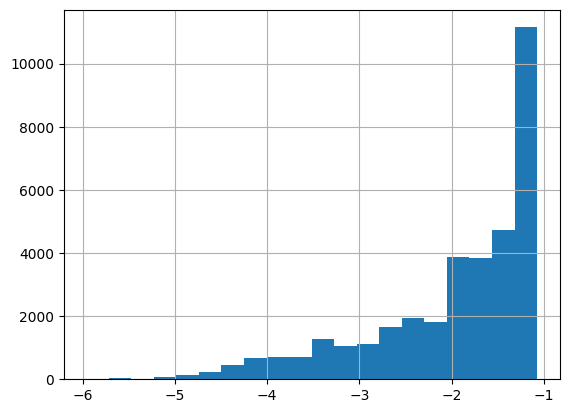

In [194]:
best_epa.hist(bins=20)